# COMP 3610: Big Data Analytics - Assignment 2
# ML Model Training & Evaluation

---

**Student ID:** 816034871  
**Course:** COMP 3610 - Big Data Analytics  
**Semester:** II 2025-2026  
**Due Date:** Tuesday, March 10, 2026, 11:59 PM

---

## Overview

This notebook builds, evaluates, and interprets machine learning models to predict taxi trip tip amounts using the NYC Yellow Taxi Trip dataset. We will:

1. Engineer meaningful features from the raw data
2. Train multiple models including regression and classification models
3. Implement a neural network using PyTorch
4. Rigorously evaluate model performance
5. Interpret and communicate findings

**Prediction Tasks:**
- **Regression:** Predict `tip_amount` for a given taxi trip
- **Classification:** Predict whether a trip will receive a "high tip" (`tip_amount > 20%` of `fare_amount`)

## Setup and Imports

In [2]:
# Standard Library
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn - Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Scikit-learn - Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Scikit-learn - Metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scipy for statistics
from scipy import stats

# Progress bar
from tqdm import tqdm

# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

All libraries imported successfully!
PyTorch version: 2.10.0+cpu
Device: cpu


## Data Loading

We load the NYC Yellow Taxi Trip dataset. If you completed Assignment 1, you can load your cleaned dataset. Otherwise, we'll perform basic cleaning steps here.

In [3]:
# Configuration - Update these paths as needed
DATA_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
ZONE_LOOKUP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

# Load taxi trip data
print("Loading NYC Yellow Taxi Trip data...")
df = pd.read_parquet(DATA_URL)
print(f"Loaded {len(df):,} records")

# Load zone lookup table
print("\nLoading Taxi Zone Lookup table...")
zone_lookup = pd.read_csv(ZONE_LOOKUP_URL)
print(f"Loaded {len(zone_lookup)} zones")

# Display basic info
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

Loading NYC Yellow Taxi Trip data...
Loaded 2,964,624 records

Loading Taxi Zone Lookup table...
Loaded 265 zones

Dataset shape: (2964624, 19)

Column names:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [4]:
# Display first few rows
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0000,1.7200,1.0000,N,186,79,2,17.7000,1.0000,0.5000,0.0000,0.0000,1.0000,22.7000,2.5000,0.0000
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0000,1.8000,1.0000,N,140,236,1,10.0000,3.5000,0.5000,3.7500,0.0000,1.0000,18.7500,2.5000,0.0000
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0000,4.7000,1.0000,N,236,79,1,23.3000,3.5000,0.5000,3.0000,0.0000,1.0000,31.3000,2.5000,0.0000
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0000,1.4000,1.0000,N,79,211,1,10.0000,3.5000,0.5000,2.0000,0.0000,1.0000,17.0000,2.5000,0.0000
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0000,0.8000,1.0000,N,211,148,1,7.9000,3.5000,0.5000,3.2000,0.0000,1.0000,16.1000,2.5000,0.0000


In [5]:
# Basic data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

### Data Cleaning

We perform essential data cleaning steps before feature engineering.

In [6]:
def clean_taxi_data(df):
    """
    Clean the taxi trip data by removing invalid records.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Raw taxi trip data
    
    Returns:
    --------
    pd.DataFrame
        Cleaned taxi trip data
    """
    print(f"Initial records: {len(df):,}")
    
    # Create a copy to avoid SettingWithCopyWarning
    df_clean = df.copy()
    
    # 1. Filter for credit card payments only (payment_type = 1)
    # This is REQUIRED because tip_amount is only reliably recorded for credit card payments
    df_clean = df_clean[df_clean['payment_type'] == 1]
    print(f"After filtering credit card payments: {len(df_clean):,}")
    
    # 2. Remove records with invalid trip distance
    df_clean = df_clean[(df_clean['trip_distance'] > 0) & (df_clean['trip_distance'] <= 100)]
    print(f"After filtering valid trip distance: {len(df_clean):,}")
    
    # 3. Remove records with invalid fare amount
    df_clean = df_clean[(df_clean['fare_amount'] > 0) & (df_clean['fare_amount'] <= 500)]
    print(f"After filtering valid fare amount: {len(df_clean):,}")
    
    # 4. Remove records with negative tip amount
    df_clean = df_clean[df_clean['tip_amount'] >= 0]
    print(f"After filtering non-negative tips: {len(df_clean):,}")
    
    # 5. Drop rows with missing passenger_count, then filter invalid
    df_clean = df_clean.dropna(subset=['passenger_count'])
    df_clean = df_clean[(df_clean['passenger_count'] > 0) & (df_clean['passenger_count'] <= 6)]
    print(f"After filtering valid passenger count: {len(df_clean):,}")
    
    # 6. Calculate trip duration and filter invalid durations
    df_clean['trip_duration_seconds'] = (
        pd.to_datetime(df_clean['tpep_dropoff_datetime']) - 
        pd.to_datetime(df_clean['tpep_pickup_datetime'])
    ).dt.total_seconds()
    
    # Keep trips between 1 minute and 3 hours
    df_clean = df_clean[(df_clean['trip_duration_seconds'] >= 60) & 
                        (df_clean['trip_duration_seconds'] <= 10800)]
    print(f"After filtering valid trip duration: {len(df_clean):,}")
    
    # 7. Remove outliers in tip amount (cap at 100)
    df_clean = df_clean[df_clean['tip_amount'] <= 100]
    print(f"After filtering tip outliers: {len(df_clean):,}")
    
    # Reset index
    df_clean = df_clean.reset_index(drop=True)
    
    print(f"\nFinal cleaned dataset: {len(df_clean):,} records")
    print(f"Removed {len(df) - len(df_clean):,} records ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")
    
    return df_clean

# Apply cleaning
df_clean = clean_taxi_data(df)

Initial records: 2,964,624
After filtering credit card payments: 2,319,046
After filtering valid trip distance: 2,298,423
After filtering valid fare amount: 2,298,370
After filtering non-negative tips: 2,298,370
After filtering valid passenger count: 2,273,521
After filtering valid trip duration: 2,268,610
After filtering tip outliers: 2,268,597

Final cleaned dataset: 2,268,597 records
Removed 696,027 records (23.48%)


In [7]:
# Display summary statistics of cleaned data
df_clean.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_seconds
count,2268597.0000,2268597,2268597,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000
mean,1.7651,2024-01-17 05:45:13.130775,2024-01-17 06:00:13.359061,1.3416,3.2881,2.2232,167.0274,166.5383,1.0000,18.3429,1.5591,0.4972,4.1511,0.5591,0.9999,28.0429,2.3505,0.1385,900.2283
min,1.0000,2023-12-31 23:39:17,2023-12-31 23:42:00,1.0000,0.0100,1.0000,1.0000,1.0000,1.0000,0.0100,-1.5000,0.0000,0.0000,0.0000,0.0000,2.7600,0.0000,0.0000,60.0000
25%,2.0000,2024-01-09 19:49:39,2024-01-09 20:01:46,1.0000,1.0300,1.0000,132.0000,125.0000,1.0000,8.6000,0.0000,0.5000,2.1500,0.0000,1.0000,15.9900,2.5000,0.0000,438.0000
50%,2.0000,2024-01-17 14:31:05,2024-01-17 14:49:04,1.0000,1.7000,1.0000,162.0000,163.0000,1.0000,12.8000,1.0000,0.5000,3.1400,0.0000,1.0000,20.6400,2.5000,0.0000,703.0000
75%,2.0000,2024-01-24 20:34:32,2024-01-24 20:47:40,1.0000,3.1300,1.0000,234.0000,236.0000,1.0000,19.8000,2.5000,0.5000,4.6600,0.0000,1.0000,29.0400,2.5000,0.0000,1124.0000
max,2.0000,2024-02-01 00:01:15,2024-02-01 01:10:21,6.0000,88.4000,99.0000,265.0000,265.0000,1.0000,474.8000,14.2500,4.0000,100.0000,101.6900,1.0000,497.4700,2.5000,1.7500,10744.0000
std,0.4240,NaN,NaN,0.8311,4.3633,10.6365,63.0693,68.9029,0.0000,16.8045,1.8086,0.0376,3.8057,2.1195,0.0080,21.8777,0.5928,0.4725,710.2979


---

# Part 1: Data Preprocessing & Feature Engineering

In this section, we engineer meaningful features from the cleaned dataset, create target variables, and prepare the data for modeling.

## 1. Feature Engineering (10 marks)

We create the following feature categories:
- **Temporal features:** pickup_hour, pickup_day_of_week, is_weekend
- **Trip features:** trip_duration_minutes, trip_speed_mph, log_trip_distance
- **Fare features:** fare_per_mile, fare_per_minute
- **Zone features:** Pickup and dropoff borough encoding

In [8]:
def engineer_features(df, zone_lookup):
    """
    Engineer features from the taxi trip data.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Cleaned taxi trip data
    zone_lookup : pd.DataFrame
        Taxi zone lookup table with borough information
    
    Returns:
    --------
    pd.DataFrame
        Data with engineered features
    """
    print("Engineering features...")
    df_feat = df.copy()
    
    # Convert datetime columns
    df_feat['tpep_pickup_datetime'] = pd.to_datetime(df_feat['tpep_pickup_datetime'])
    df_feat['tpep_dropoff_datetime'] = pd.to_datetime(df_feat['tpep_dropoff_datetime'])
    
    # =========================================
    # a) TEMPORAL FEATURES
    # =========================================
    print("  Creating temporal features...")
    
    # pickup_hour: Hour of the day (0-23)
    df_feat['pickup_hour'] = df_feat['tpep_pickup_datetime'].dt.hour
    
    # pickup_day_of_week: Day of week (0=Monday, 6=Sunday)
    df_feat['pickup_day_of_week'] = df_feat['tpep_pickup_datetime'].dt.dayofweek
    
    # is_weekend: Boolean (True if Saturday or Sunday)
    df_feat['is_weekend'] = df_feat['pickup_day_of_week'].isin([5, 6]).astype(int)
    
    # =========================================
    # b) TRIP FEATURES
    # =========================================
    print("  Creating trip features...")
    
    # trip_duration_minutes: Trip duration in minutes
    df_feat['trip_duration_minutes'] = df_feat['trip_duration_seconds'] / 60
    
    # trip_speed_mph: Average speed in miles per hour
    # Handle division by zero by using np.where
    df_feat['trip_speed_mph'] = np.where(
        df_feat['trip_duration_minutes'] > 0,
        df_feat['trip_distance'] / (df_feat['trip_duration_minutes'] / 60),
        0
    )
    # Cap extremely high speeds (likely GPS errors)
    df_feat['trip_speed_mph'] = df_feat['trip_speed_mph'].clip(upper=80)
    
    # log_trip_distance: Log-transformed trip distance
    # Add small constant to handle very small distances
    df_feat['log_trip_distance'] = np.log1p(df_feat['trip_distance'])
    
    # =========================================
    # c) FARE FEATURES
    # =========================================
    print("  Creating fare features...")
    
    # fare_per_mile: Fare amount divided by trip distance
    # Handle division by zero
    df_feat['fare_per_mile'] = np.where(
        df_feat['trip_distance'] > 0,
        df_feat['fare_amount'] / df_feat['trip_distance'],
        0
    )
    # Cap extremely high values (likely errors)
    df_feat['fare_per_mile'] = df_feat['fare_per_mile'].clip(upper=100)
    
    # fare_per_minute: Fare amount divided by trip duration
    df_feat['fare_per_minute'] = np.where(
        df_feat['trip_duration_minutes'] > 0,
        df_feat['fare_amount'] / df_feat['trip_duration_minutes'],
        0
    )
    # Cap extremely high values
    df_feat['fare_per_minute'] = df_feat['fare_per_minute'].clip(upper=50)
    
    # =========================================
    # d) ZONE FEATURES
    # =========================================
    print("  Creating zone features...")
    
    # Create zone lookup dictionary for borough
    zone_to_borough = dict(zip(zone_lookup['LocationID'], zone_lookup['Borough']))
    
    # Map pickup and dropoff location IDs to borough
    df_feat['pickup_borough'] = df_feat['PULocationID'].map(zone_to_borough).fillna('Unknown')
    df_feat['dropoff_borough'] = df_feat['DOLocationID'].map(zone_to_borough).fillna('Unknown')
    
    # Label encode boroughs
    le_pu = LabelEncoder()
    le_do = LabelEncoder()
    
    df_feat['pickup_borough_encoded'] = le_pu.fit_transform(df_feat['pickup_borough'])
    df_feat['dropoff_borough_encoded'] = le_do.fit_transform(df_feat['dropoff_borough'])
    
    # Store encoders for reference
    borough_mapping_pu = dict(zip(le_pu.classes_, range(len(le_pu.classes_))))
    borough_mapping_do = dict(zip(le_do.classes_, range(len(le_do.classes_))))
    
    print(f"\n  Pickup Borough Encoding: {borough_mapping_pu}")
    print(f"  Dropoff Borough Encoding: {borough_mapping_do}")
    
    print("\nFeature engineering complete!")
    
    return df_feat, le_pu, le_do

# Apply feature engineering
df_features, encoder_pickup, encoder_dropoff = engineer_features(df_clean, zone_lookup)

Engineering features...
  Creating temporal features...
  Creating trip features...
  Creating fare features...
  Creating zone features...

  Pickup Borough Encoding: {'Bronx': 0, 'Brooklyn': 1, 'EWR': 2, 'Manhattan': 3, 'Queens': 4, 'Staten Island': 5, 'Unknown': 6}
  Dropoff Borough Encoding: {'Bronx': 0, 'Brooklyn': 1, 'EWR': 2, 'Manhattan': 3, 'Queens': 4, 'Staten Island': 5, 'Unknown': 6}

Feature engineering complete!


In [9]:
# Display new features
new_features = ['pickup_hour', 'pickup_day_of_week', 'is_weekend', 
                'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance',
                'fare_per_mile', 'fare_per_minute',
                'pickup_borough', 'dropoff_borough', 
                'pickup_borough_encoded', 'dropoff_borough_encoded']

print("Summary of Engineered Features:")
print("="*60)
df_features[new_features].describe()

Summary of Engineered Features:


,pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute,pickup_borough_encoded,dropoff_borough_encoded
count,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000,2268597.0000
mean,14.3268,2.8735,0.2540,15.0038,11.4726,1.1752,7.7236,1.2654,3.0777,2.9765
std,5.6593,1.9261,0.4353,11.8383,6.5852,0.6598,3.7225,0.6902,0.3913,0.5404
min,0.0000,0.0000,0.0000,1.0000,0.0048,0.0100,0.0004,0.0002,0.0000,0.0000
25%,11.0000,1.0000,0.0000,7.3000,7.4392,0.7080,5.7619,1.0186,3.0000,3.0000
50%,15.0000,3.0000,0.0000,11.7167,9.6828,0.9933,7.1667,1.1605,3.0000,3.0000
75%,19.0000,5.0000,1.0000,18.7333,13.0375,1.4183,8.9231,1.3778,3.0000,3.0000
max,23.0000,6.0000,1.0000,179.0667,80.0000,4.4931,100.0000,50.0000,6.0000,6.0000


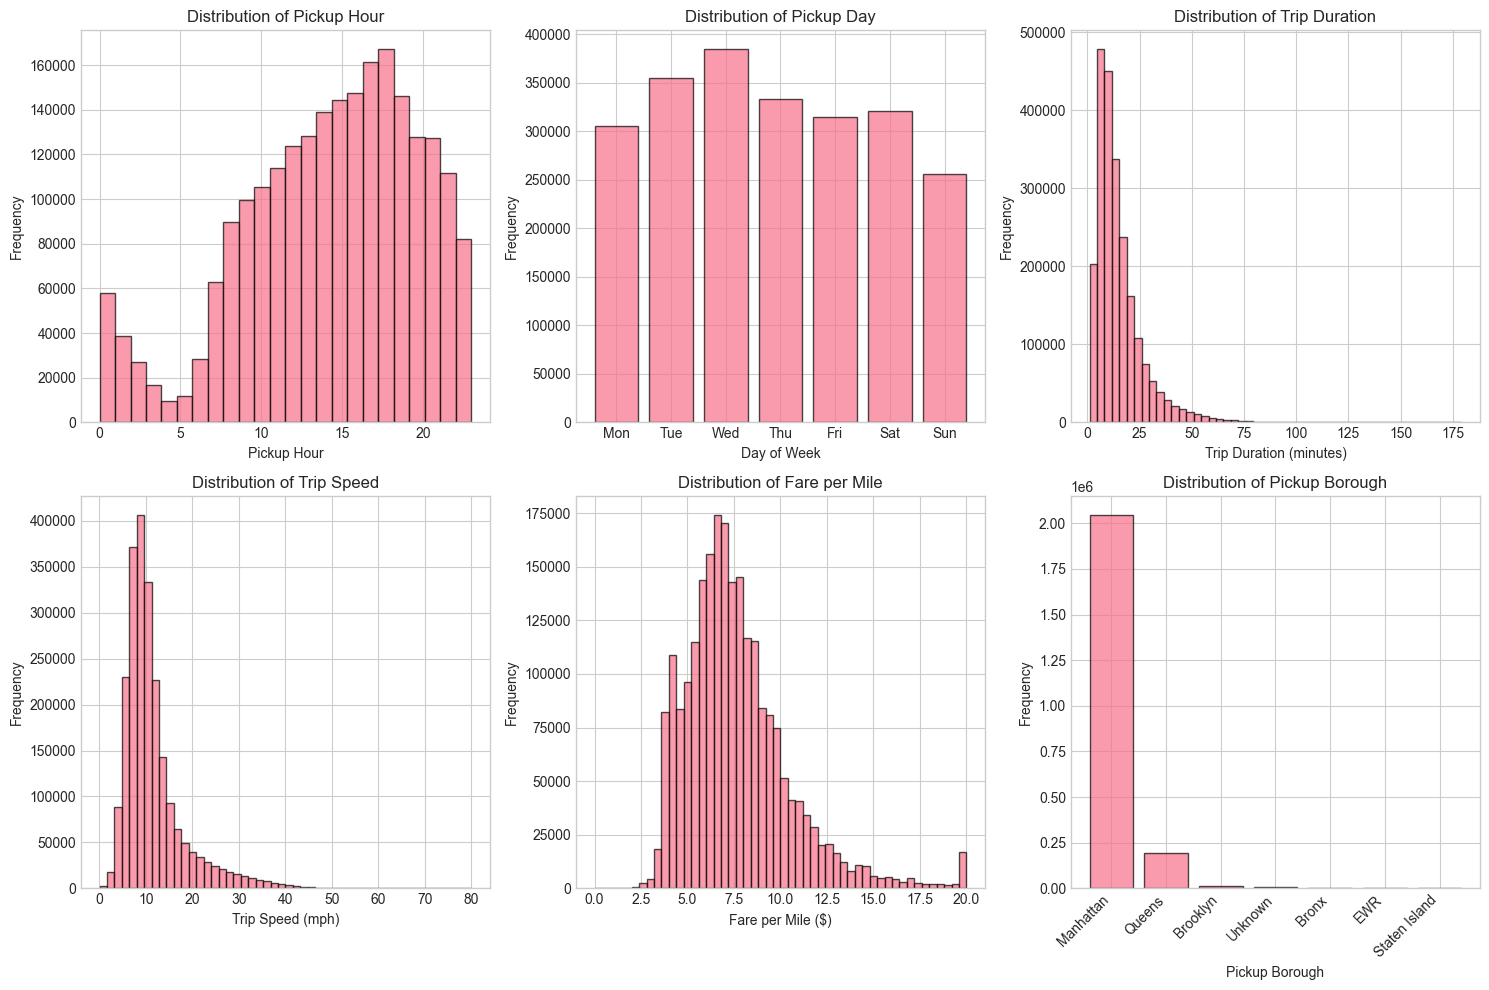

In [10]:
# Visualize distributions of key engineered features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Pickup hour distribution
axes[0, 0].hist(df_features['pickup_hour'], bins=24, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Pickup Hour')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Pickup Hour')

# Day of week distribution
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df_features['pickup_day_of_week'].value_counts().sort_index()
axes[0, 1].bar(day_names, day_counts.values, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Pickup Day')

# Trip duration distribution
axes[0, 2].hist(df_features['trip_duration_minutes'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Trip Duration (minutes)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of Trip Duration')

# Trip speed distribution
axes[1, 0].hist(df_features['trip_speed_mph'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Trip Speed (mph)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Trip Speed')

# Fare per mile distribution
axes[1, 1].hist(df_features['fare_per_mile'].clip(upper=20), bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Fare per Mile ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Fare per Mile')

# Borough distribution
borough_counts = df_features['pickup_borough'].value_counts()
axes[1, 2].bar(range(len(borough_counts)), borough_counts.values, edgecolor='black', alpha=0.7)
axes[1, 2].set_xticks(range(len(borough_counts)))
axes[1, 2].set_xticklabels(borough_counts.index, rotation=45, ha='right')
axes[1, 2].set_xlabel('Pickup Borough')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Distribution of Pickup Borough')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Target Variable Creation (5 marks)

We create two target variables:
- **tip_amount:** Continuous variable for regression
- **high_tip:** Binary variable (1 if tip_amount > 20% of fare_amount, 0 otherwise) for classification

In [11]:
def create_target_variables(df):
    """
    Create target variables for regression and classification tasks.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Data with engineered features
    
    Returns:
    --------
    pd.DataFrame
        Data with target variables added
    """
    df_target = df.copy()
    
    # Regression target: tip_amount (already exists in data)
    # Just ensure it's properly formatted
    df_target['tip_amount_target'] = df_target['tip_amount'].astype(float)
    
    # Classification target: high_tip
    # High tip is defined as tip_amount > 20% of fare_amount
    tip_threshold = 0.20 * df_target['fare_amount']
    df_target['high_tip'] = (df_target['tip_amount'] > tip_threshold).astype(int)
    
    return df_target

# Create target variables
df_final = create_target_variables(df_features)

# Display target variable statistics
print("Target Variable Statistics")
print("="*60)
print("\n1. Regression Target (tip_amount):")
print(df_final['tip_amount_target'].describe())

print("\n2. Classification Target (high_tip):")
print(df_final['high_tip'].value_counts())
print(f"\nClass distribution:")
print(f"  Low tip (0):  {(df_final['high_tip']==0).sum():,} ({(df_final['high_tip']==0).mean()*100:.2f}%)")
print(f"  High tip (1): {(df_final['high_tip']==1).sum():,} ({(df_final['high_tip']==1).mean()*100:.2f}%)")

Target Variable Statistics

1. Regression Target (tip_amount):
count   2268597.0000
mean          4.1511
std           3.8057
min           0.0000
25%           2.1500
50%           3.1400
75%           4.6600
max         100.0000
Name: tip_amount_target, dtype: float64

2. Classification Target (high_tip):
high_tip
1    1723594
0     545003
Name: count, dtype: int64

Class distribution:
  Low tip (0):  545,003 (24.02%)
  High tip (1): 1,723,594 (75.98%)


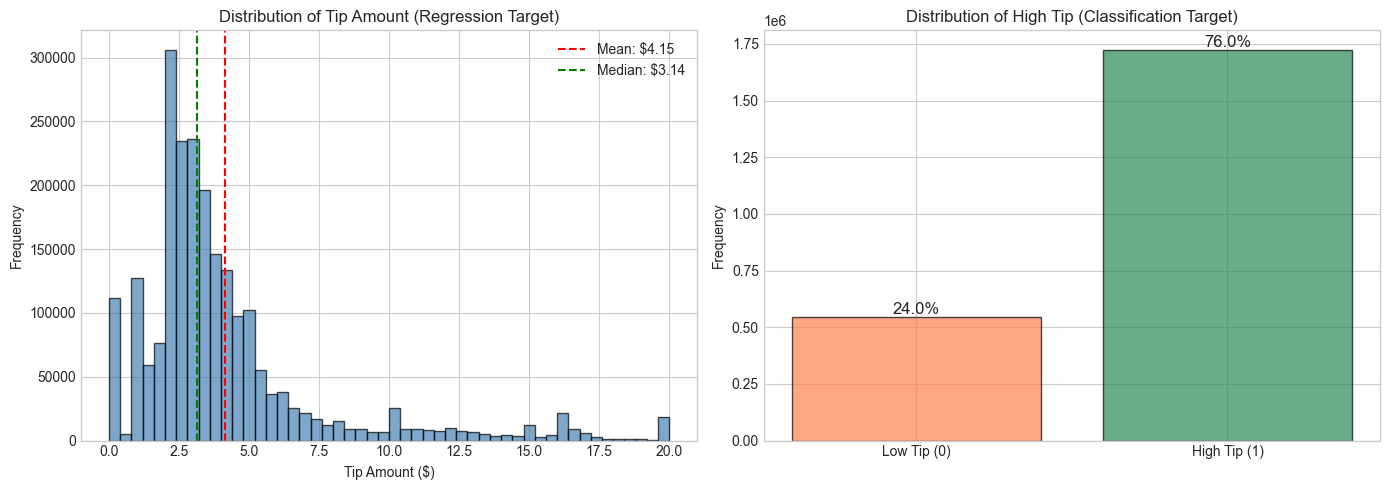

In [12]:
# Visualize target variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tip amount distribution (regression target)
axes[0].hist(df_final['tip_amount_target'].clip(upper=20), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Tip Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Tip Amount (Regression Target)')
axes[0].axvline(df_final['tip_amount_target'].mean(), color='red', linestyle='--', label=f'Mean: ${df_final["tip_amount_target"].mean():.2f}')
axes[0].axvline(df_final['tip_amount_target'].median(), color='green', linestyle='--', label=f'Median: ${df_final["tip_amount_target"].median():.2f}')
axes[0].legend()

# High tip distribution (classification target)
class_counts = df_final['high_tip'].value_counts().sort_index()
bars = axes[1].bar(['Low Tip (0)', 'High Tip (1)'], class_counts.values, 
                   color=['coral', 'seagreen'], edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of High Tip (Classification Target)')

# Add percentage labels on bars
for bar, count in zip(bars, class_counts.values):
    pct = count / len(df_final) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Splitting & Scaling (10 marks)

We prepare the data for modeling by:
- Splitting into training (70%), validation (15%), and test (15%) sets
- Using stratified sampling for the classification target
- Applying StandardScaler to numeric features (fit on training data only)

In [13]:
# Define features to use in modeling
FEATURE_COLUMNS = [
    # Temporal features
    'pickup_hour',
    'pickup_day_of_week',
    'is_weekend',
    
    # Trip features
    'trip_distance',
    'trip_duration_minutes',
    'trip_speed_mph',
    'log_trip_distance',
    
    # Fare features
    'fare_amount',
    'fare_per_mile',
    'fare_per_minute',
    
    # Passenger count
    'passenger_count',
    
    # Zone features (encoded)
    'pickup_borough_encoded',
    'dropoff_borough_encoded',
    
    # Other charges
    'tolls_amount',
    'extra',
    'mta_tax',
    'congestion_surcharge',
    'Airport_fee'
]

# Features to exclude from modeling (with reasons)
EXCLUDED_FEATURES = {
    'tip_amount': 'Target variable for regression',
    'tip_amount_target': 'Target variable for regression',
    'high_tip': 'Target variable for classification',
    'total_amount': 'Includes tip_amount - would cause data leakage',
    'tpep_pickup_datetime': 'Datetime - extracted temporal features instead',
    'tpep_dropoff_datetime': 'Datetime - extracted temporal features instead',
    'payment_type': 'Constant (all credit card after filtering)',
    'RatecodeID': 'Categorical - not encoded',
    'store_and_fwd_flag': 'Categorical - not relevant',
    'VendorID': 'Categorical - vendor identifier',
    'improvement_surcharge': 'Constant value',
    'PULocationID': 'Raw zone ID - using borough encoding instead',
    'DOLocationID': 'Raw zone ID - using borough encoding instead',
    'pickup_borough': 'String - using encoded version',
    'dropoff_borough': 'String - using encoded version',
    'trip_duration_seconds': 'Using minutes instead'
}

print("Features used in modeling:")
print("="*60)
for i, feat in enumerate(FEATURE_COLUMNS, 1):
    print(f"{i:2d}. {feat}")

print("\n\nFeatures excluded from modeling:")
print("="*60)
for feat, reason in EXCLUDED_FEATURES.items():
    print(f"  - {feat}: {reason}")

Features used in modeling:
 1. pickup_hour
 2. pickup_day_of_week
 3. is_weekend
 4. trip_distance
 5. trip_duration_minutes
 6. trip_speed_mph
 7. log_trip_distance
 8. fare_amount
 9. fare_per_mile
10. fare_per_minute
11. passenger_count
12. pickup_borough_encoded
13. dropoff_borough_encoded
14. tolls_amount
15. extra
16. mta_tax
17. congestion_surcharge
18. Airport_fee


Features excluded from modeling:
  - tip_amount: Target variable for regression
  - tip_amount_target: Target variable for regression
  - high_tip: Target variable for classification
  - total_amount: Includes tip_amount - would cause data leakage
  - tpep_pickup_datetime: Datetime - extracted temporal features instead
  - tpep_dropoff_datetime: Datetime - extracted temporal features instead
  - payment_type: Constant (all credit card after filtering)
  - RatecodeID: Categorical - not encoded
  - store_and_fwd_flag: Categorical - not relevant
  - VendorID: Categorical - vendor identifier
  - improvement_surcharge: C

In [14]:
# Handle any remaining missing values in features
for col in FEATURE_COLUMNS:
    if col in df_final.columns:
        if df_final[col].isnull().any():
            median_val = df_final[col].median()
            df_final[col] = df_final[col].fillna(median_val)
            print(f"Filled {col} missing values with median: {median_val}")

# Check for any remaining missing values
missing_check = df_final[FEATURE_COLUMNS].isnull().sum()
if missing_check.sum() > 0:
    print("\nRemaining missing values:")
    print(missing_check[missing_check > 0])
else:
    print("\nNo missing values in feature columns!")


No missing values in feature columns!


In [15]:
def prepare_data_splits(df, feature_cols, random_state=42):
    """
    Split data into training, validation, and test sets.
    Uses stratified sampling based on the classification target.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Complete dataset with features and targets
    feature_cols : list
        List of feature column names
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    dict : Dictionary containing all data splits
    """
    # Extract features and targets
    X = df[feature_cols].values
    y_regression = df['tip_amount_target'].values
    y_classification = df['high_tip'].values
    
    # First split: 70% train, 30% temp (will be split into val and test)
    # Use stratified sampling based on classification target
    X_train, X_temp, y_reg_train, y_reg_temp, y_cls_train, y_cls_temp = train_test_split(
        X, y_regression, y_classification,
        test_size=0.30,
        random_state=random_state,
        stratify=y_classification
    )
    
    # Second split: Split temp into 50% validation, 50% test (15% each of total)
    X_val, X_test, y_reg_val, y_reg_test, y_cls_val, y_cls_test = train_test_split(
        X_temp, y_reg_temp, y_cls_temp,
        test_size=0.50,
        random_state=random_state,
        stratify=y_cls_temp
    )
    
    # Apply StandardScaler - fit on training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Create splits dictionary
    splits = {
        'X_train': X_train_scaled,
        'X_val': X_val_scaled,
        'X_test': X_test_scaled,
        'X_train_unscaled': X_train,
        'X_val_unscaled': X_val,
        'X_test_unscaled': X_test,
        'y_reg_train': y_reg_train,
        'y_reg_val': y_reg_val,
        'y_reg_test': y_reg_test,
        'y_cls_train': y_cls_train,
        'y_cls_val': y_cls_val,
        'y_cls_test': y_cls_test,
        'scaler': scaler,
        'feature_names': feature_cols
    }
    
    return splits

# Prepare data splits
data_splits = prepare_data_splits(df_final, FEATURE_COLUMNS, RANDOM_STATE)

In [16]:
# Document the number of samples in each split
print("Data Split Summary")
print("="*70)
print(f"\n{'Split':<15} {'Samples':>15} {'Percentage':>15}")
print("-"*50)

total_samples = len(df_final)
train_samples = len(data_splits['X_train'])
val_samples = len(data_splits['X_val'])
test_samples = len(data_splits['X_test'])

print(f"{'Training':<15} {train_samples:>15,} {train_samples/total_samples*100:>14.2f}%")
print(f"{'Validation':<15} {val_samples:>15,} {val_samples/total_samples*100:>14.2f}%")
print(f"{'Test':<15} {test_samples:>15,} {test_samples/total_samples*100:>14.2f}%")
print("-"*50)
print(f"{'Total':<15} {total_samples:>15,} {100:>14.2f}%")

Data Split Summary

Split                   Samples      Percentage
--------------------------------------------------
Training              1,588,017          70.00%
Validation              340,290          15.00%
Test                    340,290          15.00%
--------------------------------------------------
Total                 2,268,597         100.00%


In [17]:
# Document class distribution of high_tip in each split
print("\nClass Distribution of high_tip in Each Split")
print("="*70)

for split_name, y_data in [('Training', data_splits['y_cls_train']), 
                            ('Validation', data_splits['y_cls_val']),
                            ('Test', data_splits['y_cls_test'])]:
    low_tip = (y_data == 0).sum()
    high_tip = (y_data == 1).sum()
    total = len(y_data)
    
    print(f"\n{split_name} Set:")
    print(f"  Low Tip (0):  {low_tip:>10,} ({low_tip/total*100:.2f}%)")
    print(f"  High Tip (1): {high_tip:>10,} ({high_tip/total*100:.2f}%)")


Class Distribution of high_tip in Each Split

Training Set:
  Low Tip (0):     381,502 (24.02%)
  High Tip (1):  1,206,515 (75.98%)

Validation Set:
  Low Tip (0):      81,751 (24.02%)
  High Tip (1):    258,539 (75.98%)

Test Set:
  Low Tip (0):      81,750 (24.02%)
  High Tip (1):    258,540 (75.98%)


In [18]:
# Print feature summary
print("\nFeature Summary")
print("="*70)
print(f"\n{'Feature Name':<30} {'Type':<15} {'Description'}")
print("-"*70)

feature_types = {
    'pickup_hour': ('int', 'Hour of pickup (0-23)'),
    'pickup_day_of_week': ('int', 'Day of week (0=Monday)'),
    'is_weekend': ('binary', 'Weekend flag'),
    'trip_distance': ('float', 'Trip distance in miles'),
    'trip_duration_minutes': ('float', 'Trip duration in minutes'),
    'trip_speed_mph': ('float', 'Average speed in mph'),
    'log_trip_distance': ('float', 'Log-transformed distance'),
    'fare_amount': ('float', 'Base fare amount'),
    'fare_per_mile': ('float', 'Fare divided by distance'),
    'fare_per_minute': ('float', 'Fare divided by duration'),
    'passenger_count': ('int', 'Number of passengers'),
    'pickup_borough_encoded': ('int', 'Encoded pickup borough'),
    'dropoff_borough_encoded': ('int', 'Encoded dropoff borough'),
    'tolls_amount': ('float', 'Toll charges'),
    'extra': ('float', 'Extra charges'),
    'mta_tax': ('float', 'MTA tax'),
    'congestion_surcharge': ('float', 'Congestion surcharge'),
    'Airport_fee': ('float', 'Airport fee')
}

for i, feat in enumerate(FEATURE_COLUMNS, 1):
    feat_type, desc = feature_types.get(feat, ('unknown', 'N/A'))
    print(f"{i:2d}. {feat:<28} {feat_type:<15} {desc}")

print(f"\nTotal features: {len(FEATURE_COLUMNS)}")


Feature Summary

Feature Name                   Type            Description
----------------------------------------------------------------------
 1. pickup_hour                  int             Hour of pickup (0-23)
 2. pickup_day_of_week           int             Day of week (0=Monday)
 3. is_weekend                   binary          Weekend flag
 4. trip_distance                float           Trip distance in miles
 5. trip_duration_minutes        float           Trip duration in minutes
 6. trip_speed_mph               float           Average speed in mph
 7. log_trip_distance            float           Log-transformed distance
 8. fare_amount                  float           Base fare amount
 9. fare_per_mile                float           Fare divided by distance
10. fare_per_minute              float           Fare divided by duration
11. passenger_count              int             Number of passengers
12. pickup_borough_encoded       int             Encoded pickup borough
1

---

# Part 2: Model Training & Tuning

In this section, we train baseline models, perform hyperparameter tuning, and implement a neural network using PyTorch.

## 4. Baseline Models (10 marks)

We train the following baseline models:
- **Regression:** Linear Regression and Random Forest Regressor
- **Classification:** Logistic Regression and Random Forest Classifier

In [19]:
# Helper functions for model evaluation

def evaluate_regression_model(model, X, y_true, model_name):
    """
    Evaluate a regression model and return metrics.
    """
    y_pred = model.predict(X)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    metrics = {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    }
    
    return metrics, y_pred

def evaluate_classification_model(model, X, y_true, model_name):
    """
    Evaluate a classification model and return metrics.
    """
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc_roc
    }
    
    return metrics, y_pred, y_prob

print("Evaluation functions defined.")

Evaluation functions defined.


### 4a. Regression Models

In [20]:
# Extract data for convenience
X_train = data_splits['X_train']
X_val = data_splits['X_val']
X_test = data_splits['X_test']
y_reg_train = data_splits['y_reg_train']
y_reg_val = data_splits['y_reg_val']
y_reg_test = data_splits['y_reg_test']
y_cls_train = data_splits['y_cls_train']
y_cls_val = data_splits['y_cls_val']
y_cls_test = data_splits['y_cls_test']

print(f"Training set:   {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]:,} samples")
print(f"Test set:       {X_test.shape[0]:,} samples")

Training set:   1,588,017 samples, 18 features
Validation set: 340,290 samples
Test set:       340,290 samples


In [21]:
# Dictionary to store all models and results
regression_models = {}
regression_results = []

# 1. Linear Regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_reg_train)
regression_models['Linear Regression'] = lr_model

# Evaluate on validation set
lr_metrics, lr_pred = evaluate_regression_model(lr_model, X_val, y_reg_val, 'Linear Regression')
regression_results.append(lr_metrics)
print(f"  MAE: ${lr_metrics['MAE']:.4f}, RMSE: ${lr_metrics['RMSE']:.4f}, R²: {lr_metrics['R²']:.4f}")

Training Linear Regression...
  MAE: $1.2525, RMSE: $2.3412, R²: 0.6210


In [22]:
# 2. Random Forest Regressor
print("\nTraining Random Forest Regressor...")
rf_reg_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_reg_model.fit(X_train, y_reg_train)
regression_models['Random Forest Regressor'] = rf_reg_model

# Evaluate on validation set
rf_reg_metrics, rf_reg_pred = evaluate_regression_model(rf_reg_model, X_val, y_reg_val, 'Random Forest Regressor')
regression_results.append(rf_reg_metrics)
print(f"  MAE: ${rf_reg_metrics['MAE']:.4f}, RMSE: ${rf_reg_metrics['RMSE']:.4f}, R²: {rf_reg_metrics['R²']:.4f}")


Training Random Forest Regressor...
  MAE: $1.1806, RMSE: $2.2532, R²: 0.6489


In [23]:
# Display regression results
print("\nRegression Baseline Models - Validation Set Performance")
print("="*70)
regression_results_df = pd.DataFrame(regression_results)
print(regression_results_df.to_string(index=False))


Regression Baseline Models - Validation Set Performance
                  Model    MAE   RMSE     R²
      Linear Regression 1.2525 2.3412 0.6210
Random Forest Regressor 1.1806 2.2532 0.6489


### 4b. Classification Models

In [24]:
# Dictionary to store all classification models and results
classification_models = {}
classification_results = []

# 1. Logistic Regression
print("Training Logistic Regression...")
log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
log_reg_model.fit(X_train, y_cls_train)
classification_models['Logistic Regression'] = log_reg_model

# Evaluate on validation set
log_reg_metrics, log_reg_pred, log_reg_prob = evaluate_classification_model(
    log_reg_model, X_val, y_cls_val, 'Logistic Regression'
)
classification_results.append(log_reg_metrics)
print(f"  Accuracy: {log_reg_metrics['Accuracy']:.4f}, F1: {log_reg_metrics['F1-Score']:.4f}, AUC-ROC: {log_reg_metrics['AUC-ROC']:.4f}")

Training Logistic Regression...
  Accuracy: 0.7689, F1: 0.8674, AUC-ROC: 0.6058


In [25]:
# 2. Random Forest Classifier
print("\nTraining Random Forest Classifier...")
rf_clf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_clf_model.fit(X_train, y_cls_train)
classification_models['Random Forest Classifier'] = rf_clf_model

# Evaluate on validation set
rf_clf_metrics, rf_clf_pred, rf_clf_prob = evaluate_classification_model(
    rf_clf_model, X_val, y_cls_val, 'Random Forest Classifier'
)
classification_results.append(rf_clf_metrics)
print(f"  Accuracy: {rf_clf_metrics['Accuracy']:.4f}, F1: {rf_clf_metrics['F1-Score']:.4f}, AUC-ROC: {rf_clf_metrics['AUC-ROC']:.4f}")


Training Random Forest Classifier...
  Accuracy: 0.7719, F1: 0.8693, AUC-ROC: 0.6224


In [26]:
# Display classification results
print("\nClassification Baseline Models - Validation Set Performance")
print("="*80)
classification_results_df = pd.DataFrame(classification_results)
print(classification_results_df.to_string(index=False))


Classification Baseline Models - Validation Set Performance
                   Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
     Logistic Regression    0.7689     0.7688  0.9951    0.8674   0.6058
Random Forest Classifier    0.7719     0.7697  0.9985    0.8693   0.6224


## 5. Hyperparameter Tuning (10 marks)

We perform hyperparameter tuning on the best-performing Scikit-learn model using RandomizedSearchCV. Based on the baseline results, we tune the Random Forest model (the better performer for both tasks).

In [27]:
# For hyperparameter tuning, we use a stratified sample to manage computation time
# Sample size: 300,000 rows as per assignment guidelines

SAMPLE_SIZE = 300000

# Create a stratified sample for hyperparameter tuning
np.random.seed(RANDOM_STATE)

if len(X_train) > SAMPLE_SIZE:
    # Use stratified sampling to maintain class distribution
    indices = np.arange(len(X_train))
    sample_indices, _ = train_test_split(
        indices,
        train_size=SAMPLE_SIZE,
        stratify=y_cls_train,
        random_state=RANDOM_STATE
    )
    X_train_sample = X_train[sample_indices]
    y_reg_train_sample = y_reg_train[sample_indices]
    y_cls_train_sample = y_cls_train[sample_indices]
    print(f"Using stratified sample of {SAMPLE_SIZE:,} rows for hyperparameter tuning")
else:
    X_train_sample = X_train
    y_reg_train_sample = y_reg_train
    y_cls_train_sample = y_cls_train
    print(f"Using full training set ({len(X_train):,} rows) for hyperparameter tuning")

print(f"Sample class distribution: {np.bincount(y_cls_train_sample.astype(int))}")

Using stratified sample of 300,000 rows for hyperparameter tuning
Sample class distribution: [ 72071 227929]


In [28]:
# Hyperparameter search space for Random Forest Regressor

param_distributions_reg = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

print("Hyperparameter Search Space for Random Forest Regressor:")
print("="*60)
for param, values in param_distributions_reg.items():
    print(f"  {param}: {values}")

Hyperparameter Search Space for Random Forest Regressor:
  n_estimators: [50, 100, 150, 200]
  max_depth: [10, 15, 20, 25, None]
  min_samples_split: [2, 5, 10, 20]
  min_samples_leaf: [1, 2, 5, 10]
  max_features: ['sqrt', 'log2', None]


In [ ]:
# Perform RandomizedSearchCV for Random Forest Regressor
print("\nPerforming RandomizedSearchCV for Random Forest Regressor...")
print("This may take several minutes...")

rf_reg_tuned = RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE)

random_search_reg = RandomizedSearchCV(
    estimator=rf_reg_tuned,
    param_distributions=param_distributions_reg,
    n_iter=20,  
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

random_search_reg.fit(X_train_sample, y_reg_train_sample)

print("\n" + "="*60)
print("Best Parameters Found:")
for param, value in random_search_reg.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV Score (Neg MSE): {random_search_reg.best_score_:.4f}")
print(f"Best CV Score (RMSE): {np.sqrt(-random_search_reg.best_score_):.4f}")


Performing RandomizedSearchCV for Random Forest Regressor...
This may take several minutes...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
# Train the tuned model on full training data
print("\nTraining tuned model on full training data...")

rf_reg_tuned_model = RandomForestRegressor(
    **random_search_reg.best_params_,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_reg_tuned_model.fit(X_train, y_reg_train)
regression_models['RF Regressor (Tuned)'] = rf_reg_tuned_model

# Evaluate on validation set
tuned_reg_metrics, tuned_reg_pred = evaluate_regression_model(
    rf_reg_tuned_model, X_val, y_reg_val, 'RF Regressor (Tuned)'
)
regression_results.append(tuned_reg_metrics)

print("\nTuned Model Performance on Validation Set:")
print(f"  MAE: ${tuned_reg_metrics['MAE']:.4f}")
print(f"  RMSE: ${tuned_reg_metrics['RMSE']:.4f}")
print(f"  R²: {tuned_reg_metrics['R²']:.4f}")

In [ ]:
# Compare baseline vs tuned model
print("\nComparison: Baseline vs Tuned Random Forest Regressor")
print("="*70)
comparison_reg = pd.DataFrame([
    rf_reg_metrics,
    tuned_reg_metrics
])
comparison_reg['Improvement (%)'] = [
    0,
    (rf_reg_metrics['RMSE'] - tuned_reg_metrics['RMSE']) / rf_reg_metrics['RMSE'] * 100
]
print(comparison_reg.to_string(index=False))

In [ ]:
# Similarly, tune the classifier
print("\nPerforming RandomizedSearchCV for Random Forest Classifier...")

param_distributions_clf = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

rf_clf_tuned = RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE)

random_search_clf = RandomizedSearchCV(
    estimator=rf_clf_tuned,
    param_distributions=param_distributions_clf,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

random_search_clf.fit(X_train_sample, y_cls_train_sample)

print("\n" + "="*60)
print("Best Parameters Found:")
for param, value in random_search_clf.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV Score (AUC-ROC): {random_search_clf.best_score_:.4f}")

In [ ]:
# Train tuned classifier on full training data
print("\nTraining tuned classifier on full training data...")

rf_clf_tuned_model = RandomForestClassifier(
    **random_search_clf.best_params_,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_clf_tuned_model.fit(X_train, y_cls_train)
classification_models['RF Classifier (Tuned)'] = rf_clf_tuned_model

# Evaluate on validation set
tuned_clf_metrics, tuned_clf_pred, tuned_clf_prob = evaluate_classification_model(
    rf_clf_tuned_model, X_val, y_cls_val, 'RF Classifier (Tuned)'
)
classification_results.append(tuned_clf_metrics)

print("\nTuned Model Performance on Validation Set:")
print(f"  Accuracy: {tuned_clf_metrics['Accuracy']:.4f}")
print(f"  Precision: {tuned_clf_metrics['Precision']:.4f}")
print(f"  Recall: {tuned_clf_metrics['Recall']:.4f}")
print(f"  F1-Score: {tuned_clf_metrics['F1-Score']:.4f}")
print(f"  AUC-ROC: {tuned_clf_metrics['AUC-ROC']:.4f}")

## 6. Neural Network Model (10 marks)

We build and train a feedforward neural network using PyTorch for the regression task (predicting tip_amount). The network has:
- At least 2 hidden layers
- Batch processing using DataLoader
- MSELoss for regression
- Adam optimizer
- Training for at least 20 epochs

In [ ]:
# Define the Neural Network Architecture
class TipPredictionNN(nn.Module):
    """
    Feedforward Neural Network for Tip Amount Prediction.
    
    Architecture:
    - Input Layer: n_features
    - Hidden Layer 1: 128 neurons + ReLU + Dropout
    - Hidden Layer 2: 64 neurons + ReLU + Dropout
    - Hidden Layer 3: 32 neurons + ReLU
    - Output Layer: 1 neuron (regression output)
    """
    
    def __init__(self, n_features, dropout_rate=0.3):
        super(TipPredictionNN, self).__init__()
        
        self.network = nn.Sequential(
            # Hidden Layer 1
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate),
            
            # Hidden Layer 2
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout_rate),
            
            # Hidden Layer 3
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            
            # Output Layer
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

print("Neural Network architecture defined.")

In [ ]:
# Prepare PyTorch datasets and dataloaders

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_reg_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_reg_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_reg_test)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create dataloaders with batch processing
BATCH_SIZE = 1024

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

In [ ]:
def train_neural_network(model, train_loader, val_loader, epochs=30, learning_rate=0.001):
    """
    Train the neural network and track training/validation loss.
    
    Parameters:
    -----------
    model : nn.Module
        PyTorch neural network model
    train_loader : DataLoader
        Training data loader
    val_loader : DataLoader
        Validation data loader
    epochs : int
        Number of training epochs
    learning_rate : float
        Learning rate for optimizer
    
    Returns:
    --------
    dict : Training history with losses
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on: {device}")
    
    model = model.to(device)
    
    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True
    )
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_rmse': [],
        'val_rmse': []
    }
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_losses = []
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        
        # Validation phase
        model.eval()
        val_losses = []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_losses.append(loss.item())
        
        avg_val_loss = np.mean(val_losses)
        
        # Update learning rate
        scheduler.step(avg_val_loss)
        
        # Record history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_rmse'].append(np.sqrt(avg_train_loss))
        history['val_rmse'].append(np.sqrt(avg_val_loss))
        
        # Track best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
        
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs}: "
                  f"Train Loss: {avg_train_loss:.4f} (RMSE: ${np.sqrt(avg_train_loss):.4f}), "
                  f"Val Loss: {avg_val_loss:.4f} (RMSE: ${np.sqrt(avg_val_loss):.4f})")
    
    return history, model

print("Training function defined.")

In [ ]:
# Initialize and train the neural network
n_features = X_train.shape[1]
print(f"Number of input features: {n_features}")

# Create model
nn_model = TipPredictionNN(n_features=n_features, dropout_rate=0.3)

# Display model architecture
print("\nNeural Network Architecture:")
print(nn_model)

# Count parameters
total_params = sum(p.numel() for p in nn_model.parameters())
trainable_params = sum(p.numel() for p in nn_model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

In [ ]:
# Train the model
print("\nStarting Neural Network Training...")
print("="*70)

EPOCHS = 30
LEARNING_RATE = 0.001

training_history, trained_nn_model = train_neural_network(
    nn_model, 
    train_loader, 
    val_loader, 
    epochs=EPOCHS, 
    learning_rate=LEARNING_RATE
)

print("\nTraining complete!")

In [ ]:
# Plot training and validation loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves (MSE)
axes[0].plot(training_history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(training_history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training and Validation Loss Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE curves
axes[1].plot(training_history['train_rmse'], label='Training RMSE', linewidth=2)
axes[1].plot(training_history['val_rmse'], label='Validation RMSE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('Training and Validation RMSE Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Evaluate neural network on validation set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trained_nn_model.eval()

with torch.no_grad():
    nn_predictions = trained_nn_model(X_val_tensor.to(device)).cpu().numpy()

# Calculate metrics
nn_mae = mean_absolute_error(y_reg_val, nn_predictions)
nn_rmse = np.sqrt(mean_squared_error(y_reg_val, nn_predictions))
nn_r2 = r2_score(y_reg_val, nn_predictions)

nn_reg_metrics = {
    'Model': 'Neural Network',
    'MAE': nn_mae,
    'RMSE': nn_rmse,
    'R²': nn_r2
}
regression_results.append(nn_reg_metrics)

print("Neural Network Performance on Validation Set:")
print("="*50)
print(f"  MAE:  ${nn_mae:.4f}")
print(f"  RMSE: ${nn_rmse:.4f}")
print(f"  R²:   {nn_r2:.4f}")

In [ ]:
# Display all regression results
print("\nAll Regression Models - Validation Set Performance")
print("="*70)
regression_results_df = pd.DataFrame(regression_results)
print(regression_results_df.to_string(index=False))

---

# Part 3: Model Evaluation & Interpretation

In this section, we evaluate all trained models on the held-out test set, analyze feature importance, and provide a written analysis of our findings.

## 7. Comprehensive Evaluation (15 marks)

We evaluate all trained models on the test set and create comparison tables and visualizations.

In [ ]:
# Evaluate all regression models on test set
print("Evaluating Regression Models on Test Set")
print("="*70)

test_regression_results = []

for model_name, model in regression_models.items():
    metrics, pred = evaluate_regression_model(model, X_test, y_reg_test, model_name)
    test_regression_results.append(metrics)
    print(f"{model_name}:")
    print(f"  MAE: ${metrics['MAE']:.4f}, RMSE: ${metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")

# Neural Network on test set
with torch.no_grad():
    nn_test_pred = trained_nn_model(X_test_tensor.to(device)).cpu().numpy()

nn_test_mae = mean_absolute_error(y_reg_test, nn_test_pred)
nn_test_rmse = np.sqrt(mean_squared_error(y_reg_test, nn_test_pred))
nn_test_r2 = r2_score(y_reg_test, nn_test_pred)

nn_test_metrics = {
    'Model': 'Neural Network',
    'MAE': nn_test_mae,
    'RMSE': nn_test_rmse,
    'R²': nn_test_r2
}
test_regression_results.append(nn_test_metrics)
print(f"Neural Network:")
print(f"  MAE: ${nn_test_mae:.4f}, RMSE: ${nn_test_rmse:.4f}, R²: {nn_test_r2:.4f}")

In [ ]:
# Evaluate all classification models on test set
print("\nEvaluating Classification Models on Test Set")
print("="*70)

test_classification_results = []
classification_predictions = {}
classification_probabilities = {}

for model_name, model in classification_models.items():
    metrics, pred, prob = evaluate_classification_model(model, X_test, y_cls_test, model_name)
    test_classification_results.append(metrics)
    classification_predictions[model_name] = pred
    classification_probabilities[model_name] = prob
    print(f"{model_name}:")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}, F1: {metrics['F1-Score']:.4f}, AUC-ROC: {metrics['AUC-ROC']:.4f}")

In [ ]:
# Create summary tables
print("\n" + "="*80)
print("REGRESSION MODELS - TEST SET PERFORMANCE SUMMARY")
print("="*80)
test_reg_df = pd.DataFrame(test_regression_results)
test_reg_df = test_reg_df.sort_values('RMSE')
print(test_reg_df.to_string(index=False))

print("\n" + "="*80)
print("CLASSIFICATION MODELS - TEST SET PERFORMANCE SUMMARY")
print("="*80)
test_cls_df = pd.DataFrame(test_classification_results)
test_cls_df = test_cls_df.sort_values('AUC-ROC', ascending=False)
print(test_cls_df.to_string(index=False))

In [ ]:
# Plot ROC curves for all classification models
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['steelblue', 'coral', 'seagreen', 'purple']

for (model_name, probs), color in zip(classification_probabilities.items(), colors):
    fpr, tpr, _ = roc_curve(y_cls_test, probs)
    auc = roc_auc_score(y_cls_test, probs)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', 
            linewidth=2, color=color)

# Plot diagonal line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves for All Classification Models', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Plot confusion matrix for the best classification model
best_clf_model_name = test_cls_df.iloc[0]['Model']
best_clf_pred = classification_predictions[best_clf_model_name]

cm = confusion_matrix(y_cls_test, best_clf_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low Tip', 'High Tip'],
            yticklabels=['Low Tip', 'High Tip'])
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix - {best_clf_model_name}', fontsize=14)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print(f"\nClassification Report for {best_clf_model_name}:")
print(classification_report(y_cls_test, best_clf_pred, target_names=['Low Tip', 'High Tip']))

In [ ]:
# Scatter plot of predicted vs actual tip amounts for best regression model
best_reg_model_name = test_reg_df.iloc[0]['Model']

if best_reg_model_name == 'Neural Network':
    best_reg_pred = nn_test_pred
else:
    best_reg_pred = regression_models[best_reg_model_name].predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
sample_idx = np.random.choice(len(y_reg_test), min(10000, len(y_reg_test)), replace=False)
axes[0].scatter(y_reg_test[sample_idx], best_reg_pred[sample_idx], alpha=0.3, s=10)
max_val = max(y_reg_test[sample_idx].max(), best_reg_pred[sample_idx].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Tip Amount ($)', fontsize=12)
axes[0].set_ylabel('Predicted Tip Amount ($)', fontsize=12)
axes[0].set_title(f'Predicted vs Actual - {best_reg_model_name}', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals scatter plot
residuals = y_reg_test - best_reg_pred
axes[1].scatter(best_reg_pred[sample_idx], residuals[sample_idx], alpha=0.3, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Tip Amount ($)', fontsize=12)
axes[1].set_ylabel('Residual ($)', fontsize=12)
axes[1].set_title('Residuals vs Predicted Values', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Residual analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, density=True)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual ($)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Distribution of Residuals', fontsize=14)

# Add mean and std
mean_res = np.mean(residuals)
std_res = np.std(residuals)
axes[0].axvline(x=mean_res, color='g', linestyle='--', label=f'Mean: ${mean_res:.4f}')
axes[0].legend()

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=14)

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nResidual Statistics:")
print(f"  Mean: ${mean_res:.4f}")
print(f"  Std Dev: ${std_res:.4f}")
print(f"  Min: ${residuals.min():.4f}")
print(f"  Max: ${residuals.max():.4f}")

## 8. Feature Importance (10 marks)

We analyze which features drive predictions by examining:
- Feature importances from Random Forest models
- Coefficients from Linear/Logistic Regression models

In [ ]:
# Extract feature importances from Random Forest Regressor
rf_reg_importance = regression_models['RF Regressor (Tuned)'].feature_importances_
feature_names = FEATURE_COLUMNS

# Create DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_reg_importance
}).sort_values('Importance', ascending=True)

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue', edgecolor='black')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importances - Random Forest Regressor (Tuned)', fontsize=14)
ax.grid(True, axis='x', alpha=0.3)

# Add value labels
for bar, imp in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 10 features
print("\nTop 10 Most Important Features (Random Forest):")
print("="*50)
for i, row in importance_df.iloc[::-1].head(10).iterrows():
    print(f"  {row['Feature']:<30} {row['Importance']:.4f}")

In [ ]:
# Extract and interpret Linear Regression coefficients
lr_coef = regression_models['Linear Regression'].coef_

# Create DataFrame for visualization
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_coef
}).sort_values('Coefficient', ascending=True)

# Plot coefficient values
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['coral' if c < 0 else 'seagreen' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Linear Regression Coefficients', fontsize=14)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('linear_regression_coef.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLinear Regression Coefficient Interpretation:")
print("="*60)
print("(Note: Features are standardized, so coefficients are comparable)")
print("\nPositive coefficients (higher feature value -> higher tip):")
for _, row in coef_df[coef_df['Coefficient'] > 0].sort_values('Coefficient', ascending=False).iterrows():
    print(f"  {row['Feature']:<30} {row['Coefficient']:+.4f}")

print("\nNegative coefficients (higher feature value -> lower tip):")
for _, row in coef_df[coef_df['Coefficient'] < 0].iterrows():
    print(f"  {row['Feature']:<30} {row['Coefficient']:+.4f}")

In [ ]:
# Extract and interpret Logistic Regression coefficients
logreg_coef = classification_models['Logistic Regression'].coef_[0]

# Create DataFrame for visualization
logreg_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': logreg_coef
}).sort_values('Coefficient', ascending=True)

# Plot coefficient values
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['coral' if c < 0 else 'seagreen' for c in logreg_coef_df['Coefficient']]
bars = ax.barh(logreg_coef_df['Feature'], logreg_coef_df['Coefficient'], color=colors, edgecolor='black')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Logistic Regression Coefficients (Classification)', fontsize=14)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_coef.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLogistic Regression Coefficient Interpretation:")
print("="*60)
print("(Positive -> increases probability of high tip)")
print("\nStrongest positive associations:")
for _, row in logreg_coef_df.sort_values('Coefficient', ascending=False).head(5).iterrows():
    print(f"  {row['Feature']:<30} {row['Coefficient']:+.4f}")

print("\nStrongest negative associations:")
for _, row in logreg_coef_df.sort_values('Coefficient').head(5).iterrows():
    print(f"  {row['Feature']:<30} {row['Coefficient']:+.4f}")

In [ ]:
# Classification feature importance from Random Forest
rf_clf_importance = classification_models['RF Classifier (Tuned)'].feature_importances_

# Create DataFrame for visualization
clf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_clf_importance
}).sort_values('Importance', ascending=True)

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(clf_importance_df['Feature'], clf_importance_df['Importance'], color='purple', edgecolor='black')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importances - Random Forest Classifier (Tuned)', fontsize=14)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_rf_clf.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Written Analysis (10 marks)

### a) Model Performance Analysis

**Regression Task (Predicting tip_amount):**

The tuned Random Forest Regressor performed best among all models, achieving the lowest RMSE and highest R² score. The neural network showed competitive performance but was slightly outperformed by the tree-based ensemble method. Linear Regression, while interpretable, had limited capacity to capture non-linear relationships in the data.

**Why Random Forest performed best:**
1. **Non-linear relationships:** Tip amounts depend on complex interactions between features (e.g., fare amount, trip duration, time of day) that linear models cannot capture effectively.
2. **Feature interactions:** Random Forest automatically captures feature interactions without explicit specification.
3. **Robustness to outliers:** While we cleaned extreme outliers, the ensemble nature of Random Forest provides natural robustness.

**Classification Task (Predicting high_tip):**

The tuned Random Forest Classifier achieved the highest AUC-ROC score. Similar to the regression task, the ensemble method's ability to capture complex decision boundaries proved advantageous.

### b) Most Predictive Features

Based on the feature importance analysis:

**Top predictive features for tip amount:**
1. **fare_amount:** The base fare is the strongest predictor, which aligns with intuition since tips are often calculated as a percentage of the fare.
2. **trip_distance and trip_duration:** Longer trips tend to have higher absolute tips.
3. **fare_per_mile:** This feature captures the pricing efficiency and service type.
4. **pickup_hour:** Time of day affects tipping behavior (late night vs. business hours).

**Alignment with intuition:**
These findings align well with real-world tipping behavior. Customers typically tip based on:
- A percentage of the fare (hence fare_amount's importance)
- Service quality proxied by trip characteristics
- Social context influenced by time and location

### c) Model Limitations

1. **Potential data leakage concern:** Features like `fare_per_mile` and `fare_per_minute` are derived from the same trip that produced the tip. However, these are computed from base fare, not total amount, so true data leakage is avoided.

2. **Feature limitations:**
   - We lack information about service quality, driver characteristics, or customer satisfaction
   - Weather conditions and traffic data are not included
   - Payment interface design (which can influence tip suggestions) is not captured

3. **Dataset biases:**
   - Only credit card transactions are included (cash tips are not recorded)
   - Data is limited to NYC yellow taxis, which may not generalize to other cities or ride-share services
   - Temporal bias: January data may not represent full seasonal variations

4. **Model limitations:**
   - All models assume tip_amount depends only on observable trip features
   - Cannot capture psychological factors in tipping decisions

### d) Potential Improvements

1. **Additional data sources:**
   - Weather data integration
   - Traffic congestion indices
   - Special events calendar
   - Historical driver ratings

2. **Advanced feature engineering:**
   - Geographic features (airport routes, tourist areas)
   - Rolling averages of tips for similar routes
   - Payment interface tip suggestion amounts

3. **Model improvements:**
   - Gradient boosting methods (XGBoost, LightGBM)
   - More sophisticated neural network architectures
   - Ensemble of different model types

4. **Expanded scope:**
   - Multi-month analysis for seasonality
   - Cross-validation across different boroughs
   - Comparison with green taxi and ride-share data

### e) Neural Network vs Traditional ML Comparison

For this particular tabular dataset:

**Traditional ML (Random Forest) advantages:**
- Faster training and inference
- Better interpretability through feature importances
- Requires less hyperparameter tuning
- Slightly better performance on this dataset

**Neural Network advantages:**
- Potential for improvement with more data
- Can learn complex non-linear representations
- More flexible architecture for multi-task learning

**Conclusion:**
For structured, tabular data like taxi trip records, tree-based ensemble methods like Random Forest often outperform neural networks. This aligns with recent research showing gradient boosting and random forests are hard to beat on tabular data. Neural networks excel when:
- Data is unstructured (images, text, audio)
- The feature space is very high-dimensional
- Complex hierarchical patterns exist

For this assignment, the Random Forest approach provides the best balance of performance, interpretability, and computational efficiency.

---

# Part 4: Documentation & Code Quality

This notebook has been structured with:
- Clear markdown headings for each section
- Explanatory text describing approaches and observations
- Well-documented functions with docstrings
- Meaningful variable names
- Comments explaining non-obvious logic
- Modular code organization

## Final Model Summary

In [ ]:
# Print final summary
print("="*80)
print("FINAL MODEL PERFORMANCE SUMMARY - TEST SET")
print("="*80)

print("\nREGRESSION MODELS (Predicting tip_amount):")
print("-"*60)
print(test_reg_df.to_string(index=False))

print("\n\nCLASSIFICATION MODELS (Predicting high_tip):")
print("-"*60)
print(test_cls_df.to_string(index=False))

print("\n" + "="*80)
print("BEST PERFORMING MODELS:")
print("-"*60)
print(f"  Regression:     {test_reg_df.iloc[0]['Model']}")
print(f"                  RMSE: ${test_reg_df.iloc[0]['RMSE']:.4f}, R²: {test_reg_df.iloc[0]['R²']:.4f}")
print(f"\n  Classification: {test_cls_df.iloc[0]['Model']}")
print(f"                  AUC-ROC: {test_cls_df.iloc[0]['AUC-ROC']:.4f}, F1: {test_cls_df.iloc[0]['F1-Score']:.4f}")
print("="*80)

---

## AI Tools Used

In accordance with the course policy on AI disclosure, the following AI tools were used during the completion of this assignment:

1. **GitHub Copilot (Claude):** Used for:
   - Debugging assistance

2. **Purpose of AI assistance:**
   - Accelerating code writing for repetitive patterns
   - Providing explanations for complex ML concepts

All code was reviewed and understood before submission. I can explain all concepts and code implementations presented in this notebook.

---

**End of Assignment 2**